In [1]:
import sys
sys.path.append("../ingestion/python/src")
sys.path.append("../ingestion/python/LangGraph_Agent")

from utils import *
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

from silver_enrichment import *
from graph_silver_enrichment import *
from APIendpoint import PlacesAPI
from database import Database

import os
from dotenv import load_dotenv
load_dotenv(override=True)

llm = LLM()
places_api = PlacesAPI(os.getenv('MAPS_APP_KEY'))
db = Database()

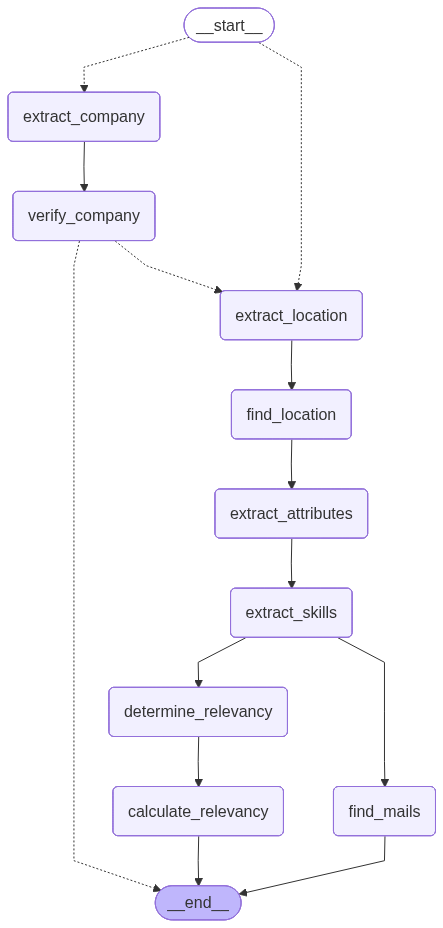

In [2]:

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# raw = db.execute("SELECT * FROM raw.job_offer WHERE company = '' LIMIT 1;")
query = ("SELECT DISTINCT ON (id_job) * "
        "FROM raw.job_offer "
        "ORDER BY id_job "
        "LIMIT 3;")


raw = db.execute(query)
states = []
for row in raw:
    states.append(map_bronze_to_JobOfferState(row))

In [15]:
raw

[{'id_job': '-4L3aQ4OSv6BXj_NAAAAAA==',
  'api_source': 'jsearch',
  'job_title': 'Ingeniero de Datos Senior GCP',
  'contract_type': 'FULLTIME',
  'job_publisher': 'BeBee',
  'company': 'Axity',
  'company_website': 'https://axity.com',
  'location_raw': 'Región Metropolitana     •  a través de BeBee',
  'city': None,
  'country': None,
  'latitude': None,
  'longitude': None,
  'is_remote': False,
  'offer_url': 'https://bebee.com/cl/jobs/ingeniero-de-datos-senior-gcp-axity--talent-622414446167335822',
  'is_direct': False,
  'source_platform': 'BeBee',
  'offer_description': 'Axity es una compañía con más de 35 años de trayectoria que ofrece un portafolio de servicios líder en la industria: Estrategia Digital, Desarrollo de Software, Business Intelligence, Big Data, Analítica Avanzada, Seguridad e IoT.\n\nResponsabilidades\n• Diseñar, desarrollar y desplegar pipelines de datos batch y streaming en Google Cloud Platform (GCP).\n• Administrar e integrar grandes volúmenes de datos en B

In [9]:
columns = ("id_offer", "raw_result")

In [ ]:


results = []
for state in states:
    r = graph.invoke(state)
    row = (r.get('id_job'), r)
    results.append(row)

Loading formatted geocoded file...


In [10]:
db.bulk_insert(table="staging.enriched_offers", columns=columns, data=results)

Query : INSERT INTO "staging"."enriched_offers" ("id_offer", "raw_result") VALUES ($1, $2) ;


In [6]:
import json
from functools import reduce
import datetime
# Fusion en un seul dictionnaire
dico_unique = reduce(lambda x, y: x | y, results)
nom_fichier = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
write_json('./test_graph',nom_fichier, dico_unique)
results


[('cj_dd5833b2d98206b5476ab3144207fb93',
  {'id_job': 'cj_dd5833b2d98206b5476ab3144207fb93',
   'id_company': None,
   'id_location': None,
   'api_source': 'careerjet',
   'job_title': 'Senior Data Engineer (Santiago)',
   'offer_description': ' are in Dublin, Ireland. Learn more at experianplc.com.   Job Description   We are looking for an experienced Senior <b>Data</b> <b>Engineer</b>...Company Description   Experian is a general <b>data</b> and technology company, powering opportunities for people',
   'contract_type': 'unknown',
   'is_remote': False,
   'job_publisher': None,
   'location_raw': 'Santiago, Región Metropolitana',
   'offer_url': 'https://jobviewtrack.com/v2/TAH9B9Tc4_EugiDgtjoNGc9-3iEDMCO9Ayzt0OZGQYvPE11OlNGNnbhXK9QiGMRXhylN0xaCn6eAEibhuQfE2ERiFFVl6nt3Amv3gM0i35TyFaRzmyeDWj_MlDdEAyAwVEHbScb8VhdkNLsSKB-0pKPBvCHslmoFQjsbSFwlhwZbX-gMXomxP2PAf3RaCFxd5-aQraHR0b4Ls_fMzEWLZhHj1TZAlrcy2xICuysOWvI',
   'source_platform': None,
   'offer_language': ['en'],
   'published_at':

In [16]:
columns = ("id_offer", "raw_result")
query = """
    SELECT DISTINCT ON (id_job) *
    FROM raw.job_offer
    ORDER BY id_job
    LIMIT 5;
"""
raw = db.execute(query)
raw

[{'id_job': '-4L3aQ4OSv6BXj_NAAAAAA==',
  'api_source': 'jsearch',
  'job_title': 'Ingeniero de Datos Senior GCP',
  'contract_type': 'FULLTIME',
  'job_publisher': 'BeBee',
  'company': 'Axity',
  'company_website': 'https://axity.com',
  'location_raw': 'Región Metropolitana     •  a través de BeBee',
  'city': None,
  'country': None,
  'latitude': None,
  'longitude': None,
  'is_remote': False,
  'offer_url': 'https://bebee.com/cl/jobs/ingeniero-de-datos-senior-gcp-axity--talent-622414446167335822',
  'is_direct': False,
  'source_platform': 'BeBee',
  'offer_description': 'Axity es una compañía con más de 35 años de trayectoria que ofrece un portafolio de servicios líder en la industria: Estrategia Digital, Desarrollo de Software, Business Intelligence, Big Data, Analítica Avanzada, Seguridad e IoT.\n\nResponsabilidades\n• Diseñar, desarrollar y desplegar pipelines de datos batch y streaming en Google Cloud Platform (GCP).\n• Administrar e integrar grandes volúmenes de datos en B

In [17]:
len(raw)

5

In [7]:
print("attributes" in states[0])

False


In [6]:
result = places_api.search_place(company="Blend360", location="Santiago, Chile")
print(result)

result2 = places_api.search_place(company="Blend360 Chile", location="")
print(result2)

None
None
